In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings(action='ignore')

## Loading the data
In this notebook, we will use Random forests to build a classifier that identify the increase or decrease of the electricity using "the data that was collected from the Australian New South Wales Electricity Market. In this market, prices are not fixed and are affected by demand and supply of the market. They are set every five minutes. Electricity transfers to/from the neighboring state of Victoria were done to alleviate fluctuations."

"The dataset contains 45,312 instances dated from 7 May 1996 to 5 December 1998. Each example of the dataset refers to a period of 30 minutes, i.e. there are 48 instances for each time period of one day. Each example on the dataset has 5 fields, the day of week, the time stamp, the New South Wales electricity demand, the Victoria electricity demand, the scheduled electricity transfer between states and the class label. The class label identifies the change of the price (UP or DOWN) in New South Wales relative to a moving average of the last 24 hours (and removes the impact of longer term price trends). Source: [Open ML electricity](https://www.openml.org/d/151).

Here are the information about the features:

* Date: date between 7 May 1996 to 5 December 1998. Here normalized between 0 and 1
* Day: day of the week (1-7)
* Period: time of the measurement (1-48) in half hour intervals over 24 hours. Here normalized between 0 and 1
* NSWprice: New South Wales electricity price, normalized between 0 and 1
* NSWdemand: New South Wales electricity demand, normalized between 0 and 1
* VICprice: Victoria electricity price, normalized between 0 and 1
* VICdemand: Victoria electricity demand, normalized between 0 and 1
* transfer: scheduled electricity transfer between both states, normalized between 0 and 1
Let's load the dataset using Sklearn `fetch_ml` function

In [3]:
from sklearn.datasets import fetch_openml

elec_data=fetch_openml(name='electricity',version=1)

In [4]:
type(elec_data)

sklearn.utils._bunch.Bunch

In [5]:
elec_data.details

{'id': '151',
 'name': 'electricity',
 'version': '1',
 'description_version': '1',
 'format': 'ARFF',
 'creator': ['M. Harries', 'J. Gama', 'A. Bifet'],
 'collection_date': '1998-12-05',
 'upload_date': '2014-04-10T02:42:23',
 'language': 'English',
 'licence': 'Public',
 'url': 'https://api.openml.org/data/v1/download/2419/electricity.arff',
 'parquet_url': 'https://data.openml.org/datasets/0000/0151/dataset_151.pq',
 'file_id': '2419',
 'default_target_attribute': 'class',
 'version_label': '1',
 'tag': ['AzurePilot',
  'concept_drift',
  'Data Science',
  'Economics',
  'electricity',
  'Kaggle',
  'mythbusting_1',
  'OpenML-CC18',
  'OpenML100',
  'study_1',
  'study_123',
  'study_135',
  'study_14',
  'study_15',
  'study_16',
  'study_20',
  'study_34',
  'study_37',
  'study_41',
  'study_7',
  'study_70',
  'study_99',
  'Sustainability'],
 'visibility': 'public',
 'original_data_url': 'http://www.inescporto.pt/~jgama/ales/ales_5.html',
 'paper_url': 'http://citeseerx.ist.psu

In [6]:
elec_data.data.shape

(45312, 8)

In [8]:
elec_data.feature_names,elec_data.target_names

(['date',
  'day',
  'period',
  'nswprice',
  'nswdemand',
  'vicprice',
  'vicdemand',
  'transfer'],
 ['class'])

In [10]:
elec_df=elec_data.frame
elec_df.head()

,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer,class
0,0.0,2,0.000000,0.056443,0.439155,0.003467,0.422915,0.414912,UP
1,0.0,2,0.021277,0.051699,0.415055,0.003467,0.422915,0.414912,UP
2,0.0,2,0.042553,0.051489,0.385004,0.003467,0.422915,0.414912,UP
3,0.0,2,0.063830,0.045485,0.314639,0.003467,0.422915,0.414912,UP
4,0.0,2,0.085106,0.042482,0.251116,0.003467,0.422915,0.414912,DOWN


In [11]:
type(elec_df)

pandas.core.frame.DataFrame

## __EDA__

In [12]:
from sklearn.model_selection import train_test_split

train_data, test_data=train_test_split(elec_df, test_size=0.25, random_state=20)
print('The size of training data is: {} \nThe size of testing data is: {}'.format(len(train_data), len(test_data)))

The size of training data is: 33984 
The size of testing data is: 11328


In [14]:
train_data.head(15)

,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer,class
27325,0.469846,4,0.276596,0.164705,0.519637,0.011417,0.657949,0.265789,DOWN
28731,0.474227,5,0.574468,0.024919,0.191907,0.001656,0.090886,0.819737,DOWN
8450,0.023141,3,0.042553,0.065270,0.250074,0.003467,0.422915,0.414912,DOWN
36659,0.889385,2,0.744681,0.148193,0.670039,0.009981,0.533402,0.563596,UP
781,0.000708,4,0.276596,0.124204,0.475454,0.003467,0.422915,0.414912,UP
13013,0.428963,7,0.106383,0.055242,0.084647,0.003467,0.422915,0.414912,DOWN
3330,0.009203,1,0.382979,0.045635,0.741892,0.003467,0.422915,0.414912,DOWN
18851,0.446662,2,0.744681,0.183409,0.785034,0.012154,0.757639,0.517105,UP
14838,0.433830,3,0.127660,0.047886,0.141476,0.003467,0.422915,0.414912,DOWN
30462,0.868236,6,0.638298,0.030833,0.702023,0.001963,0.538322,0.674123,UP


In [15]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33984 entries, 27325 to 27098
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   date       33984 non-null  float64 
 1   day        33984 non-null  category
 2   period     33984 non-null  float64 
 3   nswprice   33984 non-null  float64 
 4   nswdemand  33984 non-null  float64 
 5   vicprice   33984 non-null  float64 
 6   vicdemand  33984 non-null  float64 
 7   transfer   33984 non-null  float64 
 8   class      33984 non-null  category
dtypes: category(2), float64(7)
memory usage: 2.1 MB


Two things to draw from the dataset for now:

* The target feature class is categorical. We will make sure to encode that during data preprocessing.
* All numerical features are already normalized, so we won't need to normalize these type of features.

In [16]:
train_data.describe()

,date,period,nswprice,nswdemand,vicprice,vicdemand,transfer
count,33984.000000,33984.000000,33984.000000,33984.000000,33984.000000,33984.000000,33984.000000
mean,0.498150,0.499211,0.057922,0.424763,0.003445,0.423035,0.500089
std,0.340429,0.294571,0.040195,0.163858,0.008846,0.121087,0.153224
min,0.000000,0.000000,0.000000,0.001190,0.000000,0.000000,0.000000
25%,0.031857,0.234043,0.035247,0.307944,0.002283,0.372087,0.414912
50%,0.456307,0.489362,0.048667,0.442725,0.003467,0.422915,0.414912
75%,0.880581,0.744681,0.074276,0.535704,0.003467,0.469446,0.605263
max,1.000000,1.000000,0.981806,1.000000,1.000000,1.000000,1.000000


In [17]:
train_data.isnull().sum()

date         0
day          0
period       0
nswprice     0
nswdemand    0
vicprice     0
vicdemand    0
transfer     0
class        0
dtype: int64

Great, we don't have any missing values. Usually there are three things to do with if them if they are present:

* We can remove all missing values completely
* We can leave them as they are or
* We can fill them with a given strategy such as mean, media or most frequent value. Either Sklearn or Pandas provides a quick ways to fill these kind of values

Refer [a comprehensive article](https://medium.com/analytics-vidhya/a-comprehensive-guide-for-handling-missing-values-990c999c49ed?source=---------11----------------------------) a while back but one thing to note is that none of the above techniques is best than others. It depends on the size of your data, and your goal. Removing missing values is loosing data, and filling missing values is adding the noise in the data.

## Checking Correlation

In [21]:
X_train=train_data.drop('class',axis=1)
y_train=train_data['class']

corr=X_train.corr()


<Axes: >

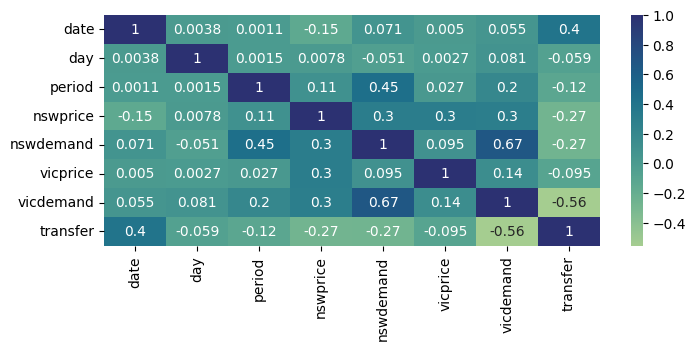

In [25]:
plt.figure(figsize=(8,3))
sns.heatmap(corr,annot=True,cmap='crest')

It seems that we don't have features which are too correlating. Correlation shown above varies from `-1 to 1`. If the correlation between two features is close to 1, it means that they nearly contain the same information. If it is close to -1, it means that these features contain different information.Take an example: `vicdemand` correlate with `nswdeman` at 0.67 ratio.

So if you drop one of those features, it's likely that your model will not be affected much. So different to what you have seen in many articles, having features which does not correlate to the target feature doesn't mean they are not useful.

In the above correlation matrix, you can see that class feature is not there and this is because it still has categorical values.

Before preprocessing the data, let's take a look into specific features.

Let's see how many Ups/Downs are in the class feature.

<Axes: xlabel='class', ylabel='count'>

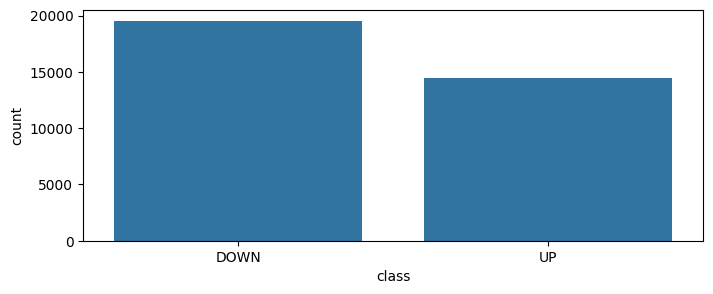

In [28]:
plt.figure(figsize=(8,3))
sns.countplot(data=train_data,x='class')

`Day` is the days of the week, from `1-7`, Monday to Sunday. Let's count the days occurences in respect to the `ups/downs` of the electricity's price

<Axes: xlabel='day', ylabel='count'>

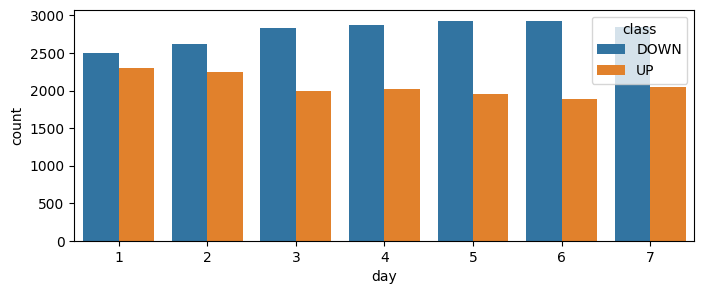

In [29]:
plt.figure(figsize=(8,3))
sns.countplot(train_data, x='day',hue='class')

It seems that most days had downs. From the beginning of the week, there were consistent increase in downs(price of electricity went down) and decrease in ups. 

Let's see if there is an appealing relationship between the demand/price of electricity in New South Wales and Victoria.

<Axes: xlabel='vicdemand', ylabel='nswdemand'>

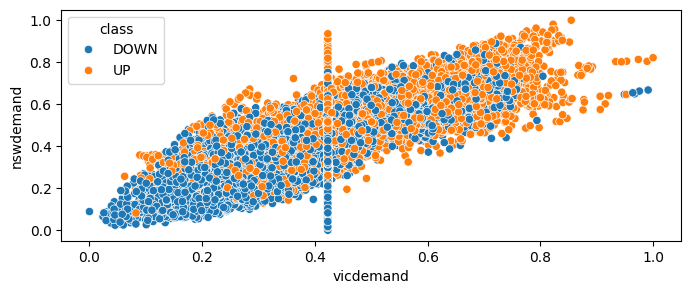

In [31]:
plt.figure(figsize=(8,3))
sns.scatterplot(data=train_data,x='vicdemand',y='nswdemand',hue='class')

The demand of the electricity in New South Wales and the Victoria is kind of linear. Let's see if we can get any other insights by bringing days in the demand analysis.

<Axes: xlabel='vicdemand', ylabel='nswdemand'>

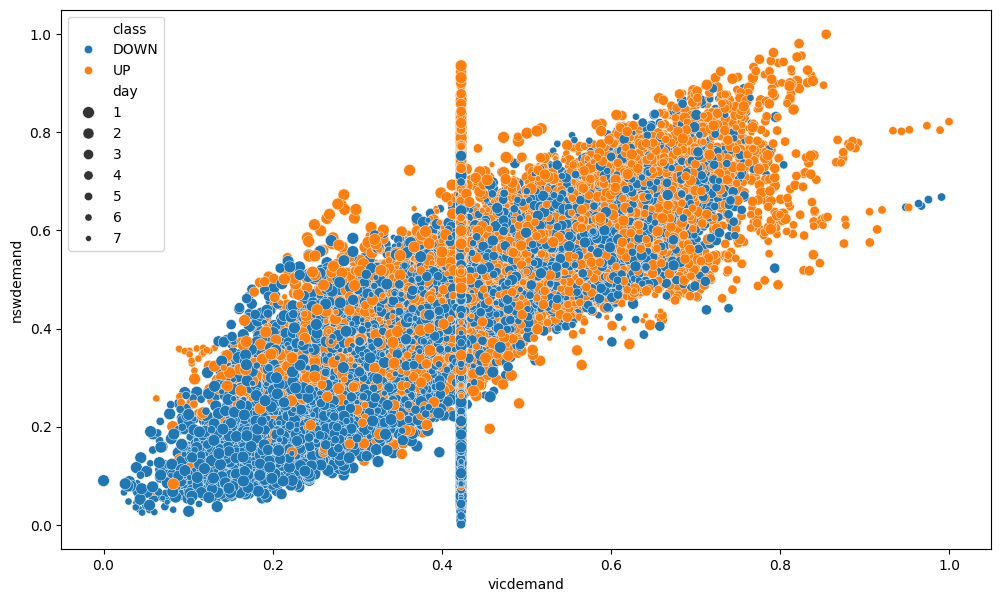

In [33]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=train_data,x='vicdemand',y='nswdemand',hue='class',size='day')

Although it is kind of hard to draw a strong point, there is less demand of electricity in both cities on Monday and Sunday than other days. We can use a line plot to plot the demand in both cities on the course of the days.

<Axes: xlabel='day', ylabel='nswdemand'>

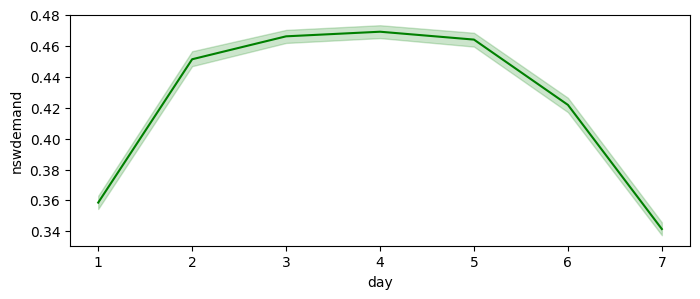

In [37]:
plt.figure(figsize=(8,3))
sns.lineplot(data=train_data, x='day', y='nswdemand', color='green')

<Axes: xlabel='day', ylabel='vicdemand'>

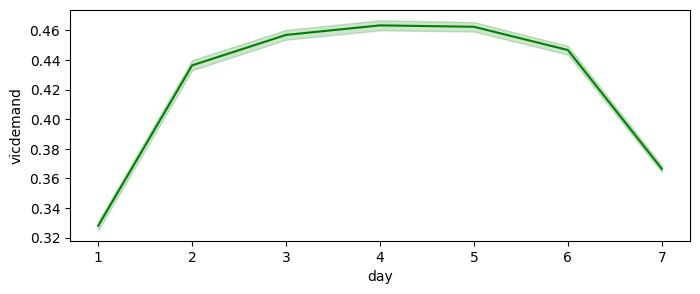

In [39]:
plt.figure(figsize=(8,3))
sns.lineplot(data=train_data, x='day', y='vicdemand', color='green')

Another interesting thing to look in the dataset is if there are some seasonalities/trends in the demand/price in either Victoria or New South Wales over period of time. In time series analysis, seasonality is when there is repetitive scenarios or consistent behaviours over the course of time. Take a different example: It has been observed that the shopping sites experience a consistent increase of page visitors at weekends. That type of example is seasonal: it always happens and in the same way, same amount, and same period.

On the other hand, the trend is a prolonged increase/decrease in a given attribute. A classic example of this is Moore's law which predicted that the number of transistors will double every two years, and that has happened 100% for so long, last 50 years or so. Moore's law were backed by the advent of microprocessors and the need of computation power. That is a trend.

In the real-life, you can have trends mixed with seasonalities. And sometimes noise can come into the picture.

I wanted to go deep to explain these time series terms, but le's come back to our analysis. If you look at the demand of the electricity in both cities on the course of date (`7 May 1996` to `5 December 1998`), you can see that there are some types of seasonalities. Not 100% but it seems there is and if this dataset would have been collected for more than two years, it would probably be easy to know surely if there are seasonalities.

<Axes: xlabel='date', ylabel='nswdemand'>

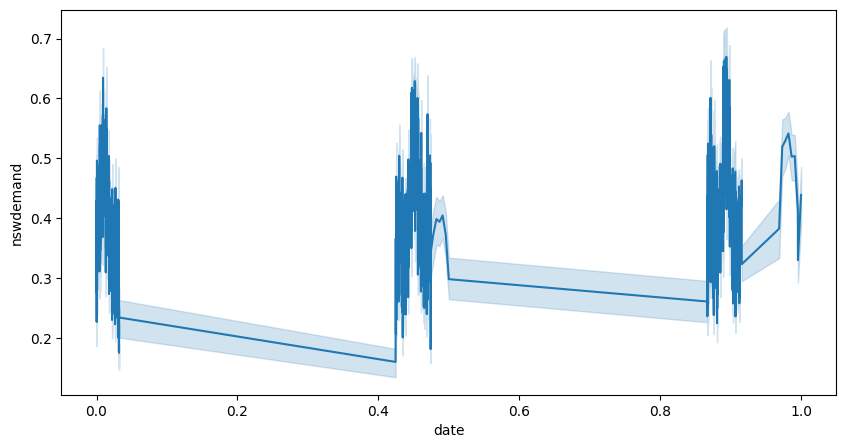

In [41]:
plt.figure(figsize=(10,5))
sns.lineplot(data=train_data, x='date', y='nswdemand')

<Axes: xlabel='date', ylabel='vicdemand'>

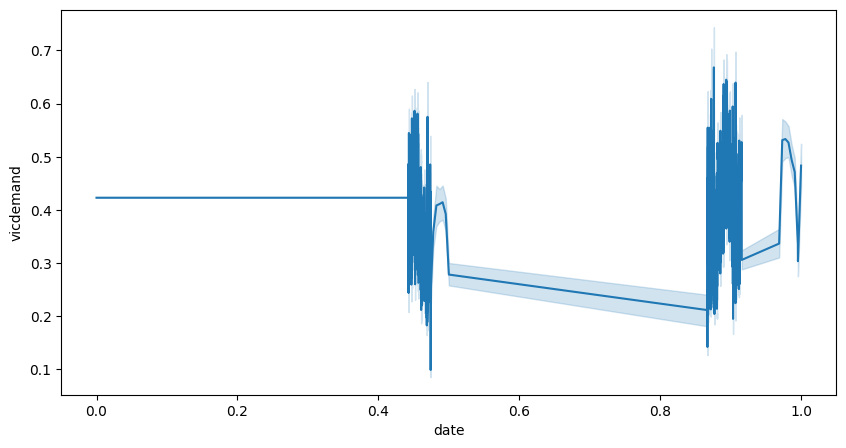

In [42]:
plt.figure(figsize=(10,5))
sns.lineplot(data=train_data, x='date', y='vicdemand')

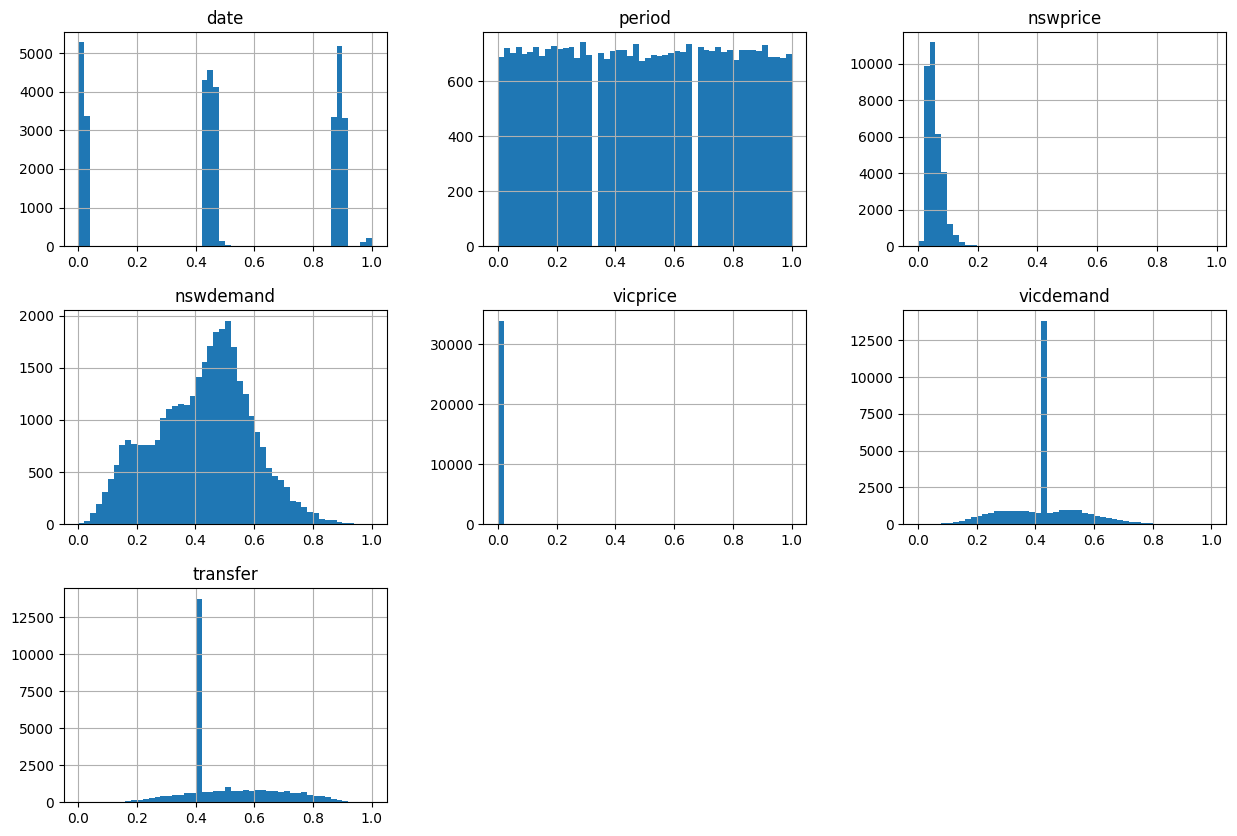

In [44]:
train_data.hist(bins=50,figsize=(15,10))
plt.show()

### Data preprocessing

In [47]:
from sklearn.preprocessing import LabelEncoder

label_enc=LabelEncoder()
y_train_prepared=label_enc.fit_transform(y_train)

Now we are ready to train the machine learning model.

But again if you look at the day, the `day` feature is not normalized as other features. We can normalize it or leave it but for now let's go ahead and train the random forests classifier.

### __Training Random Forest Classifier__

In [48]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(min_samples_split=2,bootstrap=False, max_depth=None, random_state=42,n_jobs=-1, max_features='sqrt')

forest_clf.fit(X_train, y_train_prepared)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


## __Evaluating Random Forest Classifier__

Let's build 3 functions to display accuracy, confusion matrix, and classification report.

* Accuracy provide a percentage score of the model's ability to make correct predictions
* Confusion matrix shows the predicted and the actual classes...True Negativse(TN), True Positives(TP), False Negatives(FN), and True Positives(TP).
* Classification report contains all useful metrics such as precision, recall, and f1 score..

In [49]:
from sklearn.metrics import accuracy_score

def accuracy(input_data,model,labels):
    """
    Take the input data, model and labels and return accuracy
    
    """
    
    preds = model.predict(input_data)
    acc = accuracy_score(labels,preds)
    
    return acc

In [50]:
from sklearn.metrics import confusion_matrix

def conf_matrix(input_data,model,labels):
    preds=model.predict(input_data)
    cm=confusion_matrix(labels,preds)
    return cm

In [55]:
from sklearn.metrics import classification_report

def class_report(input_data,model,labels):
    preds=model.predict(input_data)
    report=classification_report(labels,preds)
    report=print(report)
    return report

In [52]:
accuracy(X_train,forest_clf,y_train_prepared)

1.0

In [53]:
conf_matrix(X_train, forest_clf, y_train_prepared)

array([[19541,     0],
       [    0, 14443]])

In [56]:
class_report(X_train, forest_clf, y_train_prepared)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19541
           1       1.00      1.00      1.00     14443

    accuracy                           1.00     33984
   macro avg       1.00      1.00      1.00     33984
weighted avg       1.00      1.00      1.00     33984



The model clearly overfitted the data. Let's see how we can regularize it

## __Improving Random Forests__

In [57]:
forest_clf.get_params()

{'bootstrap': False,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

We will use GridSearch to find the best hyperparameters that we can use to retrain the model with. By setting the `refit` to `True`, the random forest will be automatically retrained on the dataset with the best hyperparameters. By default, `refit` is `True`.

I will also provide set `class_weight` to `balanced` since the data is not balanced. By doing that, the model will update the class weight automatically based off the number of examples available in each class.

This will take too long.

In [58]:
from sklearn.model_selection import GridSearchCV

params_grid = {
    'n_estimators':[100,200,300,500],
    'max_leaf_nodes':list(range(0,10)),
    'min_samples_leaf': [0,1,2,3,4]}

grid_search = GridSearchCV(RandomForestClassifier(bootstrap=False,class_weight='balanced', n_jobs=-1, max_features='sqrt'), params_grid, verbose=1, cv=3)

grid_search.fit(X_train, y_train_prepared)

Fitting 3 folds for each of 200 candidates, totalling 600 fits


,estimator,"RandomForestC...d', n_jobs=-1)"
,param_grid,"{'max_leaf_nodes': [0, 1, ...], 'min_samples_leaf': [0, 1, ...], 'n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [59]:
grid_search.best_params_

{'max_leaf_nodes': 9, 'min_samples_leaf': 1, 'n_estimators': 300}

In [60]:
grid_search.best_estimator_

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,9
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [61]:
forest_best=grid_search.best_estimator_

In [62]:
accuracy(X_train,forest_best,y_train_prepared)

0.7935793314500942

In [63]:
conf_matrix(X_train,forest_best,y_train_prepared)

array([[17098,  2443],
       [ 4572,  9871]])

In confusion matrix, each row represent an actual class and each column represents predicted class.

So, from the results above:

* 17098 negative examples(N) were correcty predicted as negatives(true negatives).
* 2443 negatives examples(N) were incorrectly classified as positive examples when they are in fact negatives(false positives).
* 4572 positive examples were incorrectly classified as negative(N) when in fact they are positives(P) (false negatives).
* 9871 were correctly classified as positive examples(true positives).

In [64]:
class_report(X_train,forest_best,y_train_prepared)

              precision    recall  f1-score   support

           0       0.79      0.87      0.83     19541
           1       0.80      0.68      0.74     14443

    accuracy                           0.79     33984
   macro avg       0.80      0.78      0.78     33984
weighted avg       0.79      0.79      0.79     33984



Wow, not so impressive, but this is much better than the first model. By only setting the class weight to balanced and finding the best values of the hyperparameters, we were able to improve our model. Not so great

If you remember, we have classes imbalance. You can see the number of examples in each class in support in classification report. But our model is able to identify negative examples correctly at 79%, and also is able to identify the positive examples at 80% without overfitting. That is precision.

A few notes about Precison/Recall/F1 score:

* Precision is the model accuracy on predicting positive examples correctly.
* Recall is the ratio of the positive examples that are correctly identified by the model.
* F1 score is the harmonic mean of precision and recall.\
The higher the precision and recall are, the higher the F1 score. But there is a tradeoff between them. Increasing precision will reduce recall, and vice versa. So it's fair to say that it depends on the problem you're trying to solve and the metrics you want to optimize for.

One way to improve the model can be to search more hyperparameters or adding more good data is always the best cure.

### __Evaluating the Model on the Test Set__

But I will first run the label_encoder on the class feature as I did in the training labels. Note that we only transform (not fit_transform).

In [65]:
X_test=test_data.drop('class',axis=1)
y_test=test_data['class']

y_test_prepared=label_enc.transform(y_test)

In [66]:
accuracy(X_test,forest_best,y_test_prepared)

0.7909604519774012

In [67]:
conf_matrix(X_test,forest_best,y_test_prepared)

array([[5684,  850],
       [1518, 3276]])

In [68]:
class_report(X_test,forest_best,y_test_prepared)

              precision    recall  f1-score   support

           0       0.79      0.87      0.83      6534
           1       0.79      0.68      0.73      4794

    accuracy                           0.79     11328
   macro avg       0.79      0.78      0.78     11328
weighted avg       0.79      0.79      0.79     11328



As you can see the model is no longer overfitting. On the training set, the accuracy was 79% and so on the test set. And the model never saw the test data. To improve the model in the case like this, if is often best to add more data if possible.

### __Feature Importance__

Different to other machine learning models, random forests can show how each feature contributed to the model generalization. Let's find it.

The results are values between 0 and 1. The closer to 1, the good the feature was to the model.

In [69]:
feat_import = forest_best.feature_importances_

feat_df = pd.DataFrame(feat_import, columns=['Feature Importance'], index=X_train.columns)
feat_df

,Feature Importance
date,0.055779
day,0.013909
period,0.107010
nswprice,0.475864
nswdemand,0.157456
vicprice,0.139108
vicdemand,0.038175
transfer,0.012698


From the dataframe above, the price of electricity in New South Wales had the top importance on the prediction of the electricity's cost fluctuation(Up/Down). Other features which highly influenced the model are demands in both South Wales and Victoria.